# Build a cuisine recommender

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
data = pd.read_csv("https://raw.githubusercontent.com/microsoft/ML-For-Beginners/main/5-Clustering/data/nigerian-songs.csv")
data

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525,Kwaroro,Kwaroro,J. Martins,afro dancehall,2015,193960,10,0.735,0.6320,0.918,0.193000,0.0718,-2.582,0.0355,127.954,4
526,Concert Party,Afro Escape,Various Artists,afro dancehall,2015,252708,0,0.602,0.1770,0.883,0.000004,0.1190,-6.183,0.0778,154.010,4
527,Loko,Applaudise,Iyanya,afro dancehall,2015,223159,0,0.729,0.2380,0.864,0.000000,0.1950,-3.942,0.0668,121.058,4
528,Gift,Applaudise,Iyanya,afro dancehall,2015,278280,0,0.809,0.0490,0.806,0.000000,0.0659,-6.547,0.2340,123.997,4


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530 entries, 0 to 529
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              530 non-null    object 
 1   album             530 non-null    object 
 2   artist            530 non-null    object 
 3   artist_top_genre  530 non-null    object 
 4   release_date      530 non-null    int64  
 5   length            530 non-null    int64  
 6   popularity        530 non-null    int64  
 7   danceability      530 non-null    float64
 8   acousticness      530 non-null    float64
 9   energy            530 non-null    float64
 10  instrumentalness  530 non-null    float64
 11  liveness          530 non-null    float64
 12  loudness          530 non-null    float64
 13  speechiness       530 non-null    float64
 14  tempo             530 non-null    float64
 15  time_signature    530 non-null    int64  
dtypes: float64(8), int64(4), object(4)
memory us

In [20]:
data.describe()

,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
count,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000,530.000000
mean,2015.390566,222298.169811,17.507547,0.741619,0.265412,0.760623,0.016305,0.147308,-4.953011,0.130748,116.487864,3.986792
std,3.131688,39696.822259,18.992212,0.117522,0.208342,0.148533,0.090321,0.123588,2.464186,0.092939,23.518601,0.333701
min,1998.000000,89488.000000,0.000000,0.255000,0.000665,0.111000,0.000000,0.028300,-19.362000,0.027800,61.695000,3.000000
25%,2014.000000,199305.000000,0.000000,0.681000,0.089525,0.669000,0.000000,0.075650,-6.298750,0.059100,102.961250,4.000000
50%,2016.000000,218509.000000,13.000000,0.761000,0.220500,0.784500,0.000004,0.103500,-4.558500,0.097950,112.714500,4.000000
75%,2017.000000,242098.500000,31.000000,0.829500,0.403000,0.875750,0.000234,0.164000,-3.331000,0.177000,125.039250,4.000000
max,2020.000000,511738.000000,73.000000,0.966000,0.954000,0.995000,0.910000,0.811000,0.582000,0.514000,206.007000,5.000000


In [21]:
data.isnull().sum()

,0
name,0
album,0
artist,0
artist_top_genre,0
release_date,0
length,0
popularity,0
danceability,0
acousticness,0
energy,0


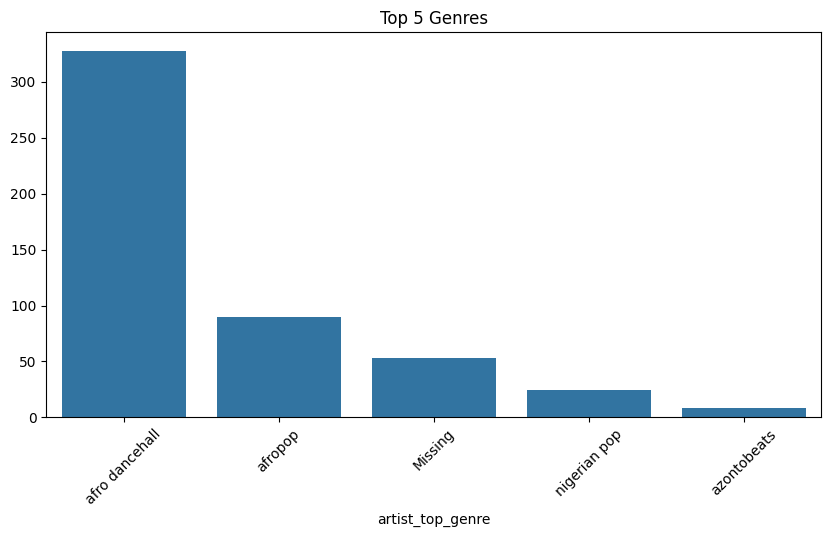

In [23]:
top = data['artist_top_genre'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=top[:5].index, y=top[:5].values)
plt.title('Top 5 Genres')
plt.xticks(rotation=45)
plt.show()

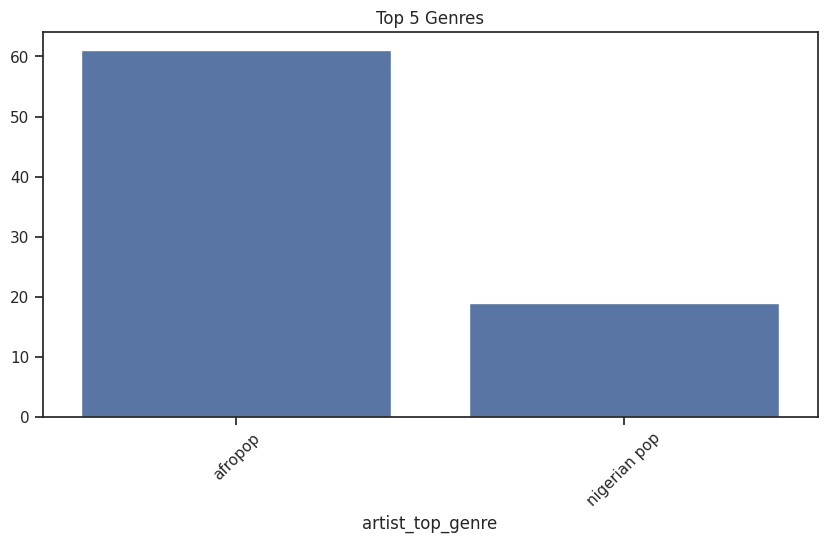

In [37]:
# There is a value of missing in the top genres list
# This must be removed
data = data[data['artist_top_genre'] != 'Missing']
top = data['artist_top_genre'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=top[:5].index, y=top[:5].values)
plt.title('Top 5 Genres')
plt.xticks(rotation=45)
plt.show()

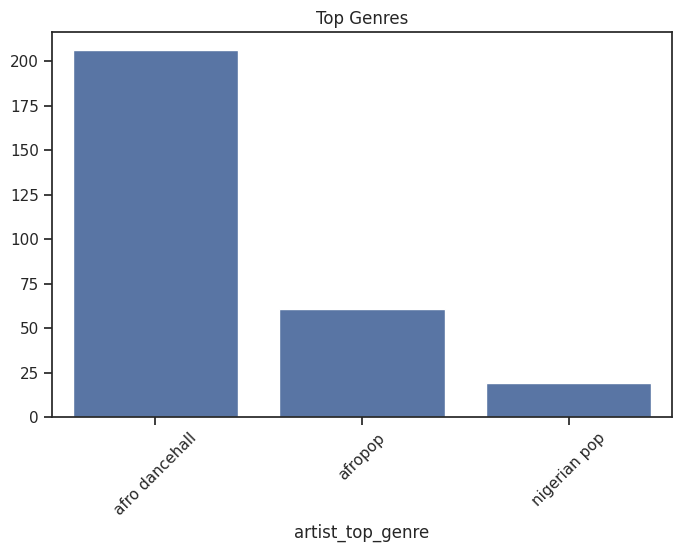

In [39]:
data = data[(data['artist_top_genre'] == 'afropop') | (data['artist_top_genre'] == 'nigerian pop') | (data['artist_top_genre'] == 'afro dancehall')]
data = data[data['popularity'] > 0]
top = data['artist_top_genre'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=top.index, y=top.values)
plt.title('Top Genres')
plt.xticks(rotation=45)
plt.show()

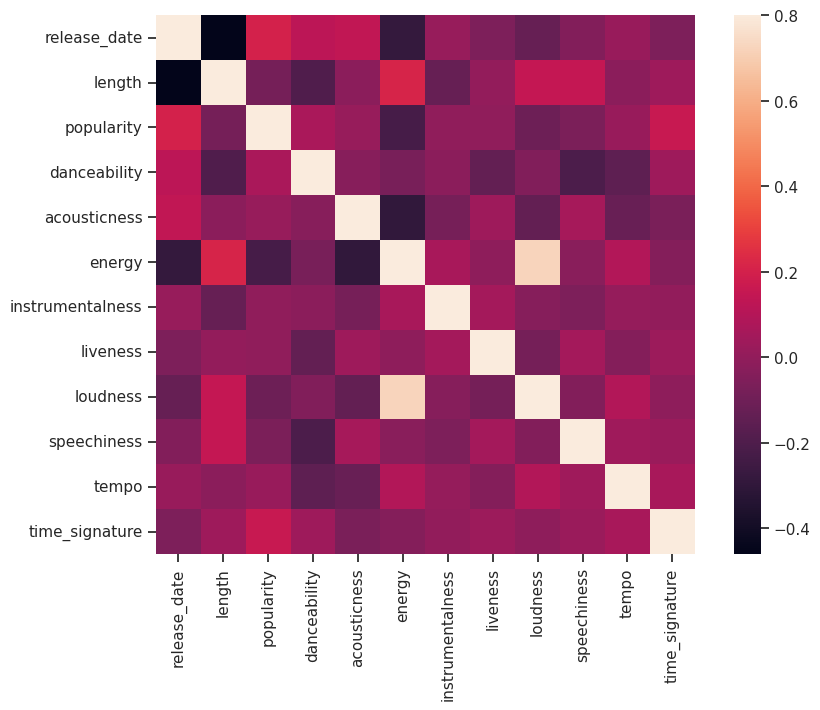

In [40]:
corrmat = data.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

In [32]:
# Check the distribution of the data
data.describe()

,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,2017.375000,203595.250000,30.462500,0.744487,0.280741,0.688087,0.019155,0.158128,-5.721362,0.125446,118.523862,4.012500
std,2.166342,38690.997211,18.993632,0.122358,0.212924,0.147003,0.113786,0.126850,2.619511,0.090931,29.940157,0.337292
min,2009.000000,89488.000000,1.000000,0.255000,0.009290,0.111000,0.000000,0.034100,-19.362000,0.031500,69.279000,3.000000
25%,2016.000000,184327.250000,14.000000,0.672250,0.127000,0.609500,0.000000,0.086150,-6.925750,0.059825,102.981750,4.000000
50%,2018.000000,206103.500000,30.000000,0.751500,0.228500,0.690500,0.000019,0.107500,-5.259500,0.092150,109.931000,4.000000
75%,2019.000000,231107.750000,45.000000,0.845250,0.379000,0.790250,0.000202,0.195000,-4.125000,0.163750,124.278000,4.000000
max,2020.000000,287555.000000,69.000000,0.951000,0.871000,0.995000,0.910000,0.622000,-0.735000,0.437000,206.007000,5.000000


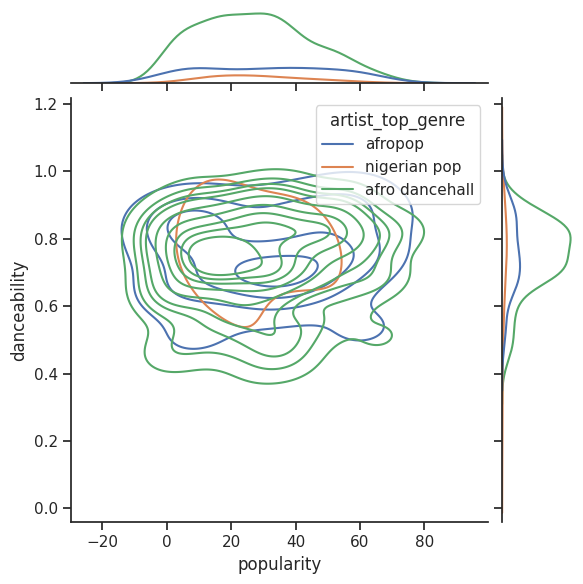

In [41]:
sns.set_theme(style='ticks')

g = sns.jointplot(
    data=data,
    x='popularity',
    y='danceability',
    kind='kde',
    hue='artist_top_genre'
)

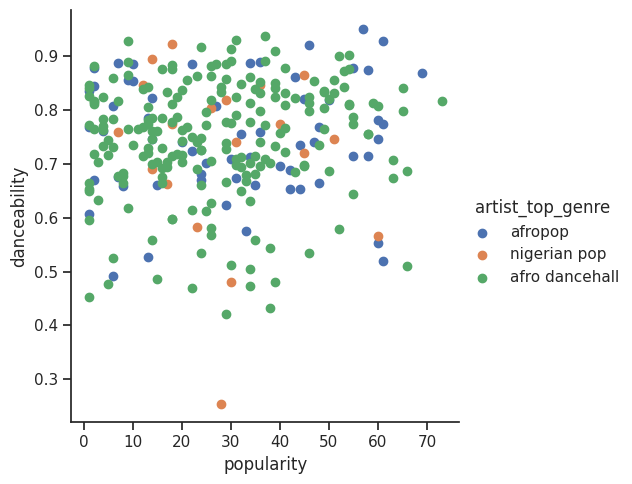

In [42]:
# Showing the clusters with a scatterplot
sns.FacetGrid(data, hue='artist_top_genre', height=5).map(plt.scatter, 'popularity', 'danceability').add_legend()

# **Training the algorithm with K-Means**

<Axes: xlabel='instrumentalness'>

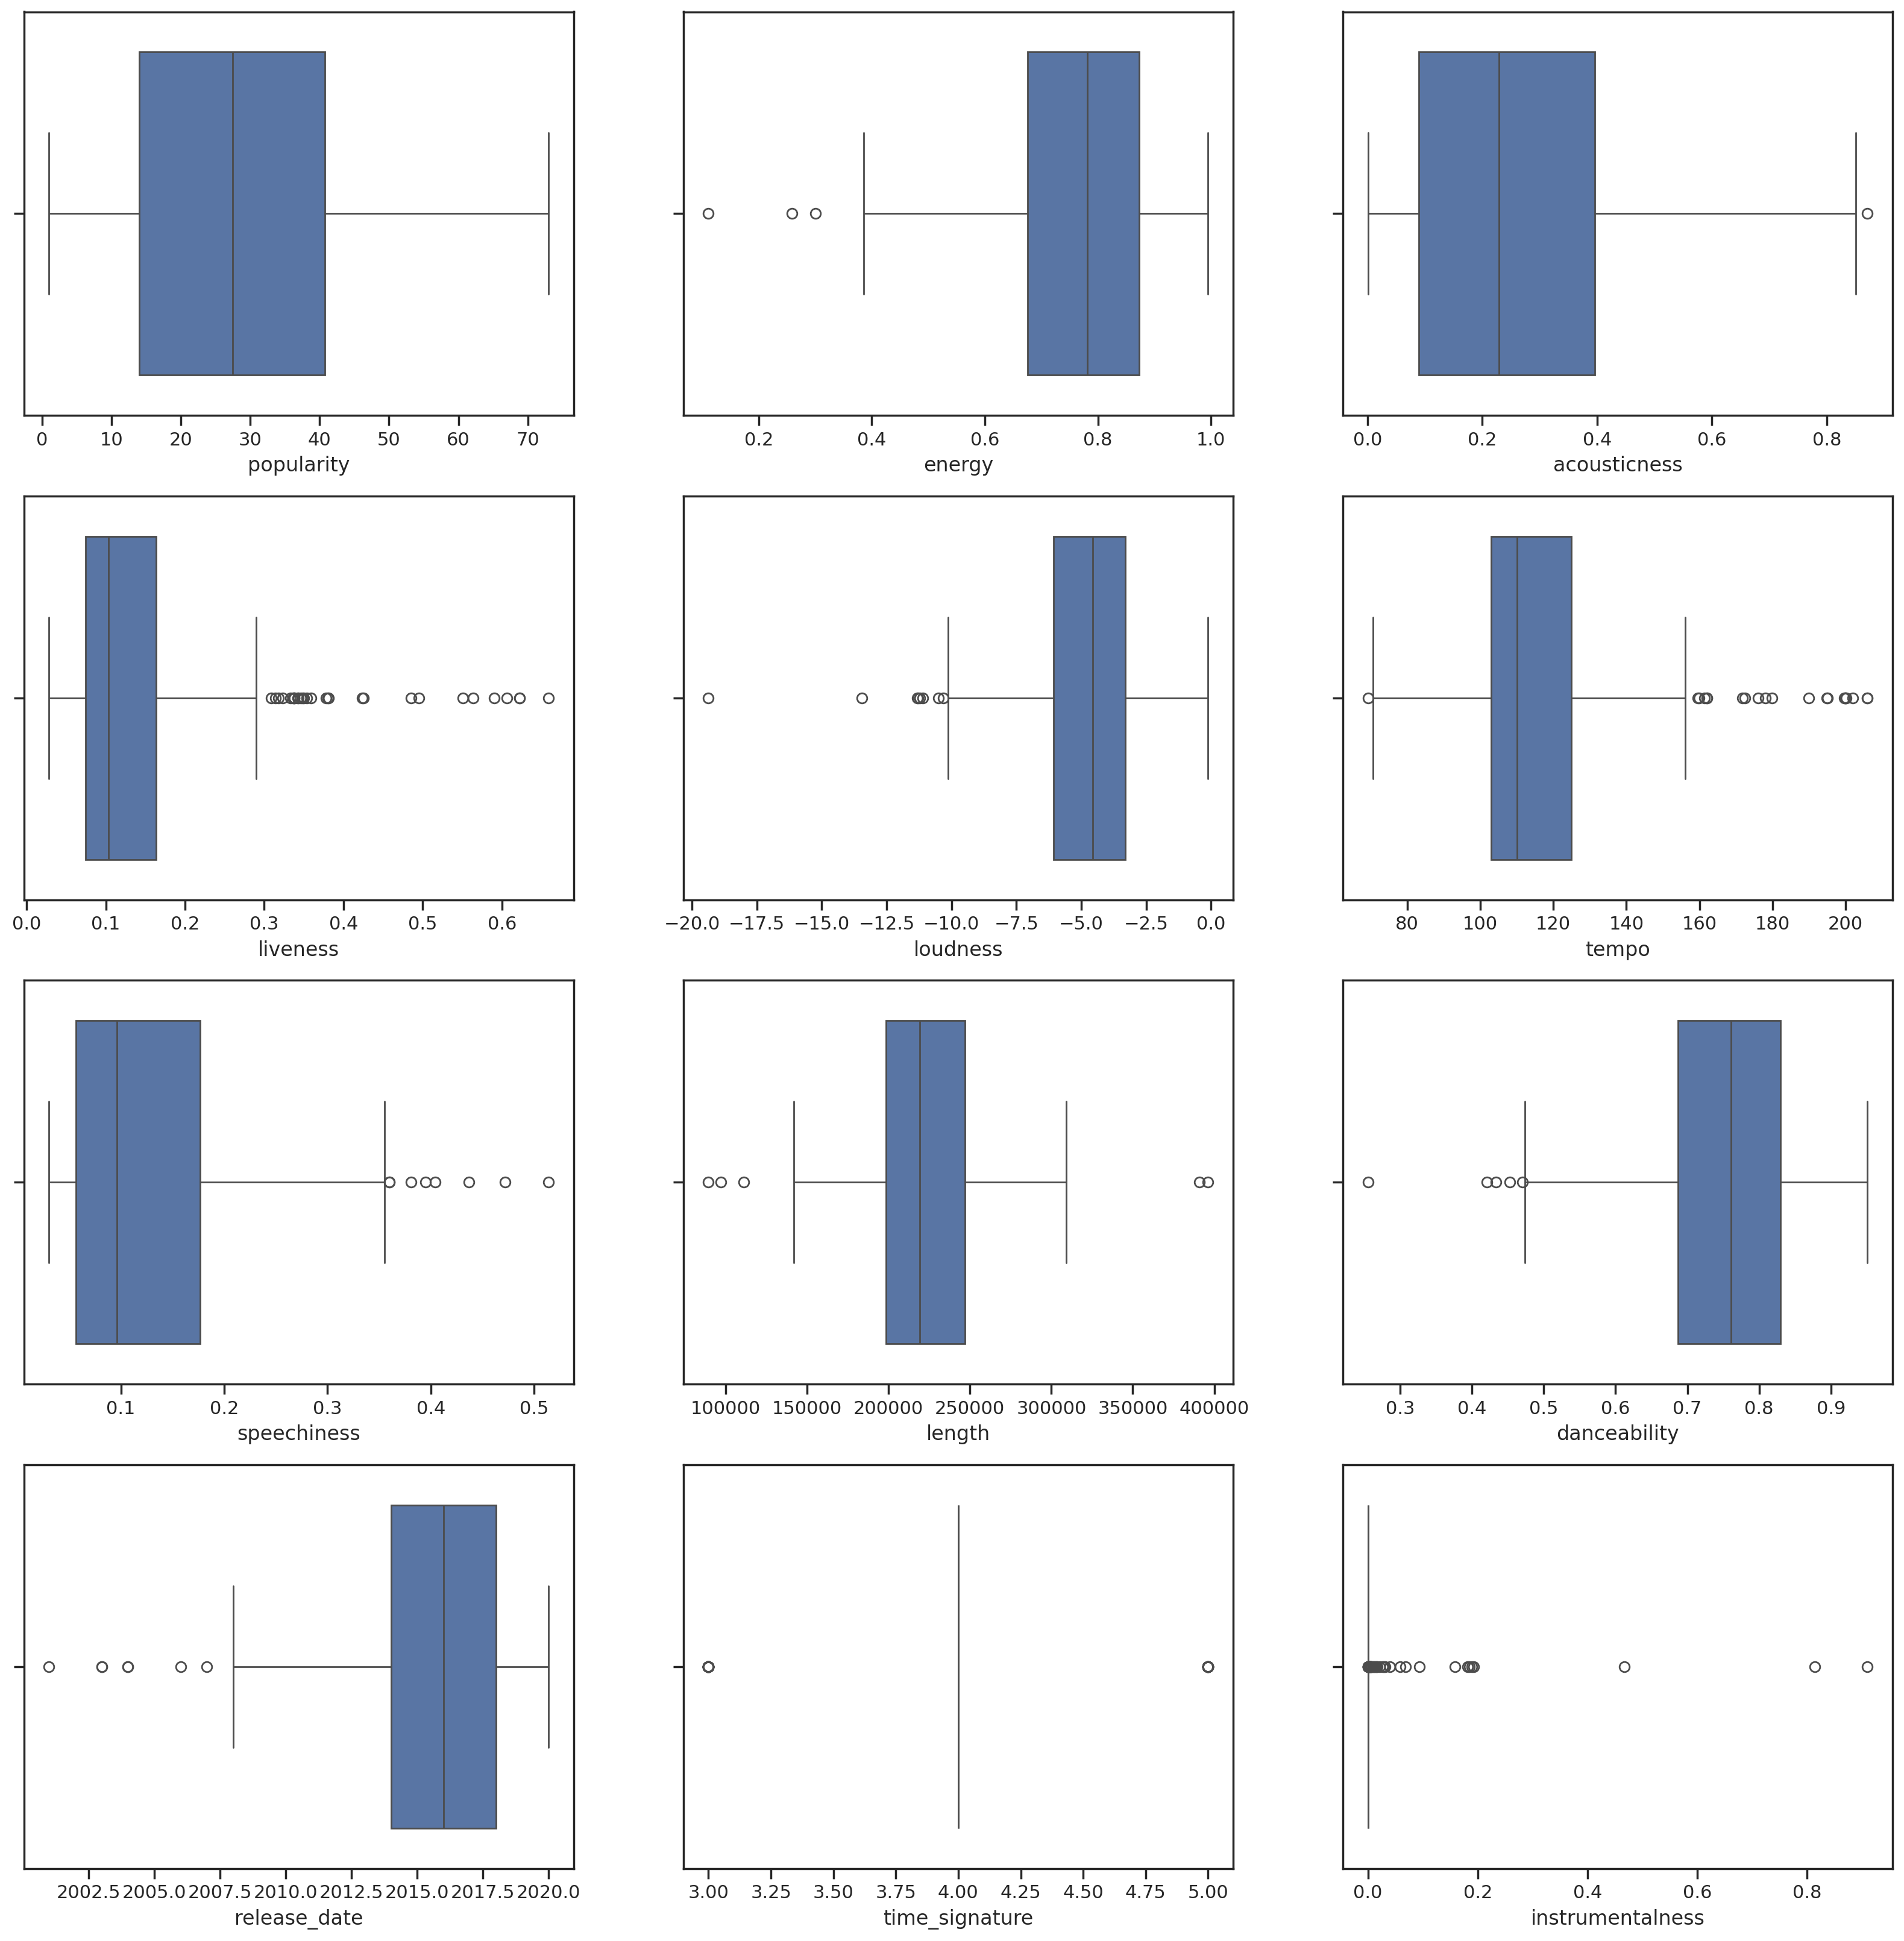

In [44]:
# create a boxplot/box-and-whisker for each column
plt.figure(figsize=(20, 20), dpi=200)

plt.subplot(4, 3, 1)
sns.boxplot(x = 'popularity', data = data)

plt.subplot(4, 3, 2)
sns.boxplot(x = 'energy', data = data)

plt.subplot(4, 3, 3)
sns.boxplot(x = 'acousticness', data = data)

plt.subplot(4, 3, 4)
sns.boxplot(x = 'liveness', data = data)

plt.subplot(4, 3, 5)
sns.boxplot(x = 'loudness', data = data)

plt.subplot(4, 3, 6)
sns.boxplot(x = 'tempo', data = data)

plt.subplot(4, 3, 7)
sns.boxplot(x = 'speechiness', data = data)

plt.subplot(4, 3, 8)
sns.boxplot(x = 'length', data = data)

plt.subplot(4, 3, 9)
sns.boxplot(x = 'danceability', data = data)

plt.subplot(4, 3, 10)
sns.boxplot(x = 'release_date', data = data)

plt.subplot(4, 3, 11)
sns.boxplot(x = 'time_signature', data = data)

plt.subplot(4, 3, 12)
sns.boxplot(x = 'instrumentalness', data = data)

In [45]:
# Time to encode the data into numerical values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

x = data.loc[:, ['artist_top_genre', 'danceability', 'popularity', 'acousticness', 'loudness', 'energy']]
y = data['artist_top_genre']
x['artist_top_genre'] = le.fit_transform(x['artist_top_genre'])

y = le.transform(y)

In [46]:
# Now we need to pick how many clusters to target
# We can use 3 for our top three genres
from sklearn.cluster import KMeans

n_clusters = 3
seed = 0

km = KMeans(n_clusters=n_clusters, random_state=seed)
km.fit(x)

# predict the cluster for each point
y_cluster_means = km.predict(x)
y_cluster_means


array([2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 2, 1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 2, 1,
       2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2,
       0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1,
       0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2,
       0, 2, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 0, 1, 0, 2, 2,
       2, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 1,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2,
       0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0],
      dtype=int32)

In [48]:
# Use the array to calculate the silhoutte score
from sklearn import metrics
score = metrics.silhouette_score(x, y_cluster_means)
score

np.float64(0.5466747351275563)

In [50]:
# The data isn't very good for clustering
# But let's build the model anyway
wcss = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

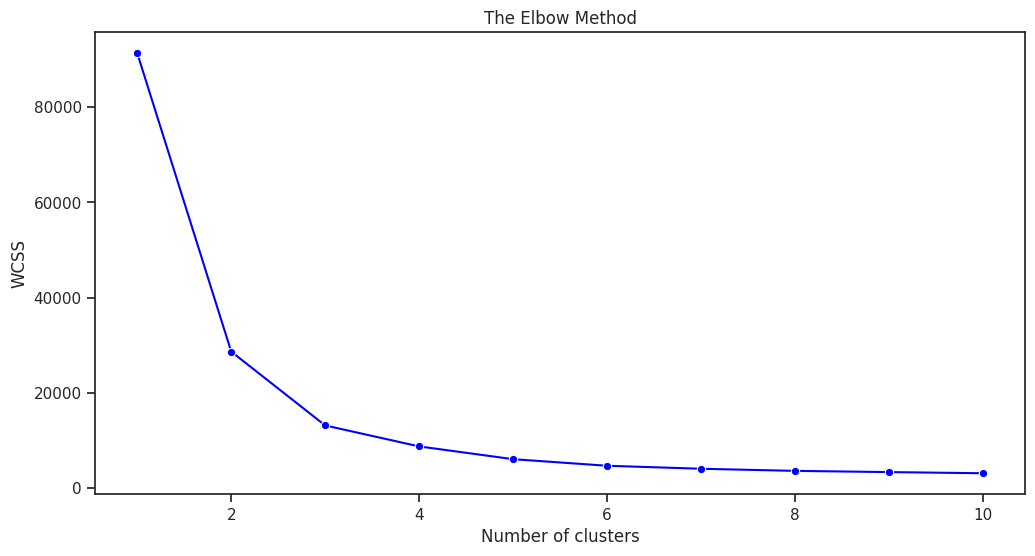

In [52]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=range(1, 11), y=wcss, marker='o', color='blue')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

Text(0.5, 0, 'Popularity')

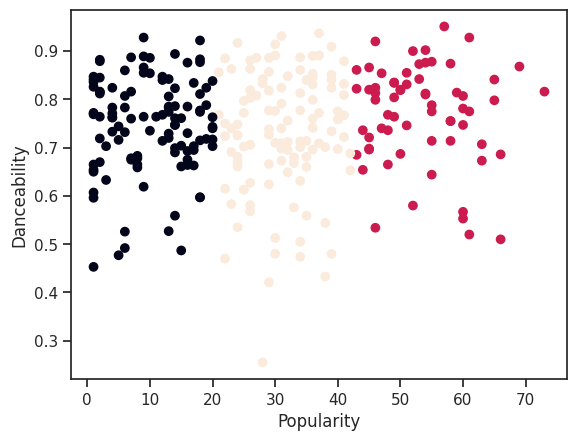

In [56]:
# We will visualise the clusters with a scatterplot
labels = km.predict(x)
plt.scatter(data['popularity'], data['danceability'], c=labels)
plt.ylabel("Danceability")
plt.xlabel("Popularity")


In [60]:
# Checking the model's accuracy
labels = km.labels_
corr_labels = sum(y == labels)
print(f"Result: {corr_labels} out of {y.size} predictions are correct.")
print(f"Accuracy score: {round(100 * (corr_labels/y.size), 3)}%")

Result: 111 out of 286 predictions are correct.
Accuracy score: 38.811%
